# Fair, Interpretable, and Actionable Readmission Risk Modeling
## Diabetes 130-US Hospitals (1999–2008)

**Digital Health & Medical Data Science Track — Project 02**

This notebook is a complete, reproducible pipeline that answers all nine clinical questions (Q1–Q9) of the project guide. It merges the two earlier notebooks: the visual EDA and patient-level baseline from `main.ipynb`, and the extended feature engineering, multi-model comparison, error analysis, explainability and fairness work from `talei.ipynb`.

**Approach summary**
- **Target:** three-class `readmitted` for EDA; binary `<30 days` vs. not for modeling (clinically actionable).
- **Leakage prevention:** the train/test split is done at the **patient** level (`patient_nbr`), stratified on whether a patient ever had an early readmission, so no patient appears on both sides.
- **Models:** a minimal logistic-regression baseline, then Logistic Regression (interpretable), Decision Tree (rules) and Gradient Boosting (stronger comparator), all with class-imbalance handling.
- **Evaluation:** recall / precision / F1 / ROC-AUC / PR-AUC, not accuracy alone; error analysis; subgroup fairness across race, gender and age.
- All figures are saved to `../figures/`.

| Phase | Questions |
|---|---|
| 1. Data preparation (آماده‌سازی داده‌ها) | Q1, Q2, Q3 + preprocessing |
| 2. Modeling & evaluation (مدل‌سازی و ارزیابی) | Q4, Q5, Q6, Q7, Q8 |
| 3. Report writing (گزارش‌نویسی) | Q9 |

## 0. Setup & Reproducibility

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, recall_score,
    precision_score, f1_score, roc_auc_score, average_precision_score, roc_curve
)

# ---- Paths -------------------------------------------------------------
DATA_PATH = Path('../data/diabetic_data.csv')
FIGURES_PATH = Path('../figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# ---- Reproducibility ---------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Visual identity ---------------------------------------------------
# One semantic palette used everywhere: teal = low risk / no readmission,
# sand = delayed readmission, coral = early readmission / increased risk.
READMIT_ORDER  = ['NO', '>30', '<30']
READMIT_COLORS = {'NO': '#2A9D8F', '>30': '#E9C46A', '<30': '#E76F51'}
RISK_UP, RISK_DOWN = '#E76F51', '#2A9D8F'
NEUTRAL, BLUE = '#264653', '#457B9D'
CMAP_SEQ, CMAP_DIV = 'Blues', 'vlag'

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05,
              palette=[BLUE, RISK_UP, RISK_DOWN, '#E9C46A', NEUTRAL])
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 110, 'savefig.dpi': 150,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.alpha': 0.4,
})

def save_fig(name):
    # Save the current figure to ../figures (call right before plt.show()).
    plt.savefig(FIGURES_PATH / f'{name}.png', bbox_inches='tight')

print('Libraries loaded. Random seed fixed at', RANDOM_STATE)

Libraries loaded. Random seed fixed at 42


## 1. Data Loading & Initial Inspection

**Phase: Data Preparation (آماده‌سازی داده‌ها).** The UCI documentation encodes missing values as `?`, so they are read as `NaN` directly.

In [2]:
df = pd.read_csv(DATA_PATH, na_values='?', low_memory=False)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print('Data types and non-null counts:')
df.info()

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14 

## Q1: What does the readmission population look like?

**Phase: Data Preparation + EDA.** We describe the target distribution, data quality (missingness, repeat patients), demographics and key utilization variables.

### Target distribution

--- Q1: Target Distribution ---
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Proportions:
readmitted
NO     0.5391
>30    0.3493
<30    0.1116
Name: proportion, dtype: float64


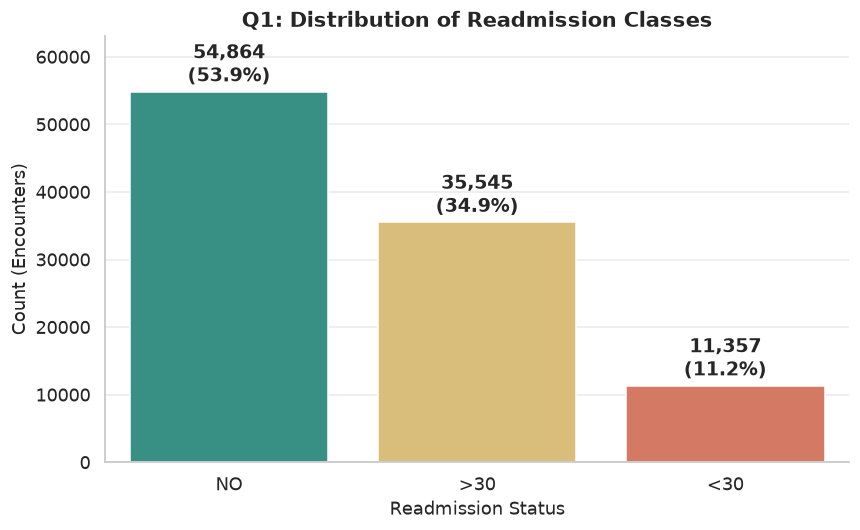

In [4]:
print("--- Q1: Target Distribution ---")
print(df['readmitted'].value_counts())
print("\nProportions:")
print(df['readmitted'].value_counts(normalize=True).round(4))

counts = df['readmitted'].value_counts().reindex(READMIT_ORDER)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='readmitted', order=READMIT_ORDER, hue='readmitted',
              hue_order=READMIT_ORDER, palette=READMIT_COLORS, legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, f'{v:,}\n({v / len(df) * 100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, counts.max() * 1.15)
ax.set_title('Q1: Distribution of Readmission Classes')
ax.set_xlabel('Readmission Status')
ax.set_ylabel('Count (Encounters)')
plt.tight_layout()
save_fig('01_target_distribution')
plt.show()

**Interpretation:** early readmission (`<30`) is a clear minority (~11% of encounters). Class imbalance must be handled in modeling and, above all, in evaluation.

### Missing values and data quality checks

--- Missing values (% of encounters) ---
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02


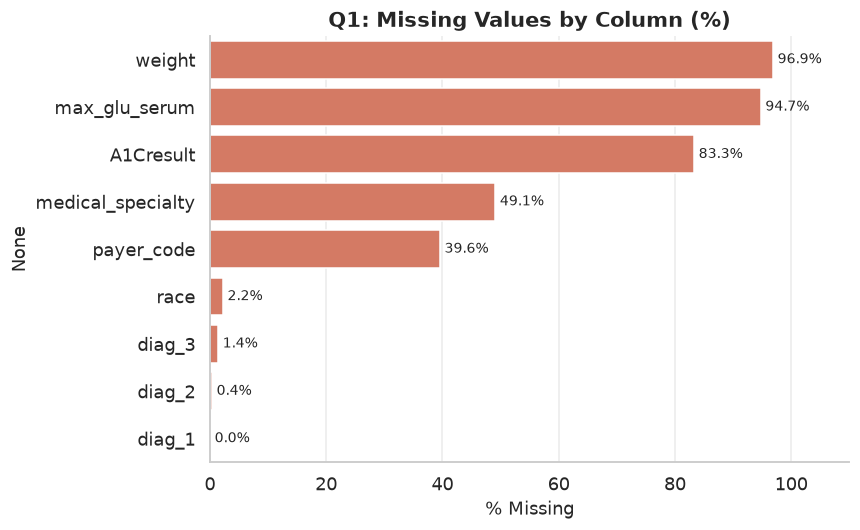

In [5]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("--- Missing values (% of encounters) ---")
print(missing_pct.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color=RISK_UP, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlim(0, 110)
ax.set_title('Q1: Missing Values by Column (%)')
ax.set_xlabel('% Missing')
plt.tight_layout()
save_fig('01_missing_values')
plt.show()

**Unusual / high-missing columns**
- `weight` (~97% missing) — dropped for modeling.
- `max_glu_serum` (~95%) and `A1Cresult` (~83%) — the lab was usually not ordered (the `None` category is read as missing); the fact that a test was *not* done is itself informative, but the columns are dropped here to keep the model simple.
- `medical_specialty` (~49%) and `payer_code` (~40%) — high missingness; dropped.
- `race` (~2%) — kept as an explicit `Unknown` category (needed for the fairness analysis).

In [6]:
print("--- Repeat Patient Encounters (critical for leakage) ---")
enc_per_patient = df.groupby('patient_nbr').size()
print(f"Total encounters: {len(df):,}")
print(f"Unique patients (patient_nbr): {df['patient_nbr'].nunique():,}")
print(f"Patients with more than 1 encounter: {(enc_per_patient > 1).sum():,} out of {df['patient_nbr'].nunique():,}")
print(f"Encounters belonging to those patients: {df['patient_nbr'].duplicated(keep=False).sum():,}")
print("\nNote: the same patient can appear many times, so the train/test split is done per patient (see modeling section).")

print("\n--- Admission Type Counts ---")
print(df['admission_type_id'].value_counts())

--- Repeat Patient Encounters (critical for leakage) ---
Total encounters: 101,766
Unique patients (patient_nbr): 71,518
Patients with more than 1 encounter: 16,773 out of 71,518
Encounters belonging to those patients: 47,021

Note: the same patient can appear many times, so the train/test split is done per patient (see modeling section).

--- Admission Type Counts ---
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64


### Demographic breakdown of patients

In [7]:
print('=== Race ===')
print(df['race'].value_counts(dropna=False))
print('\n=== Gender ===')
print(df['gender'].value_counts(dropna=False))
print('\n=== Age brackets ===')
print(df['age'].value_counts().sort_index())

=== Race ===
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

=== Gender ===
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

=== Age brackets ===
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


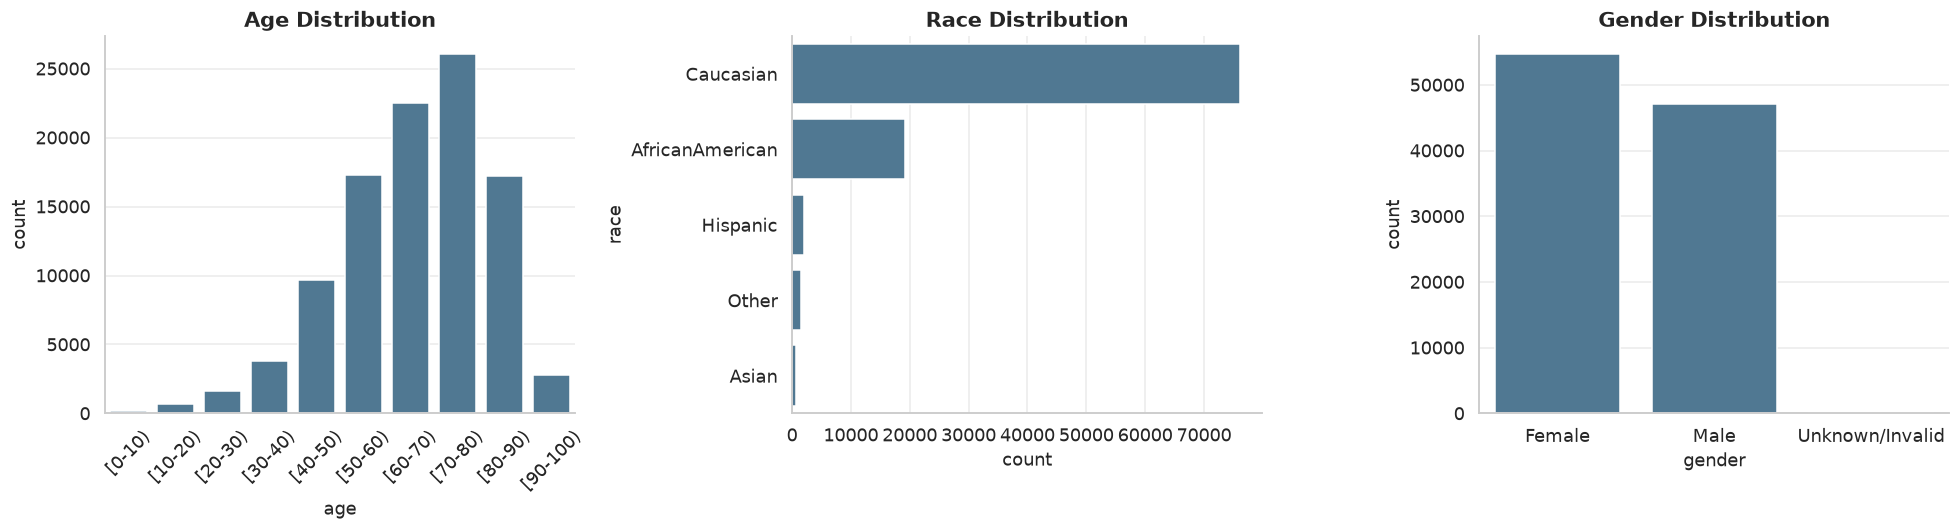

In [8]:
AGE_ORDER = sorted(df['age'].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='age', order=AGE_ORDER, color=BLUE, ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, y='race', order=df['race'].value_counts().index, color=BLUE, ax=axes[1])
axes[1].set_title('Race Distribution')

sns.countplot(data=df, x='gender', color=BLUE, ax=axes[2])
axes[2].set_title('Gender Distribution')

plt.tight_layout()
save_fig('01_demographics')
plt.show()

### Key utilization variables

In [9]:
util_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
             'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
df[util_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


## Q2: Which measurements differ most across readmission groups?

**Phase: Data Preparation / EDA.**

In [10]:
metrics = util_cols

print("--- Q2: Summary Statistics Across Readmission Groups ---")
for metric in metrics:
    print(f"\nMetric: {metric}")
    print(df.groupby('readmitted')[metric].describe().reindex(READMIT_ORDER).round(2))

print('\n=== Mean values by readmitted class (compact view) ===')
df.groupby('readmitted')[metrics].mean().round(2).reindex(READMIT_ORDER)

--- Q2: Summary Statistics Across Readmission Groups ---

Metric: time_in_hospital
              count  mean   std  min  25%  50%  75%   max
readmitted                                               
NO          54864.0  4.25  2.96  1.0  2.0  3.0  6.0  14.0
>30         35545.0  4.50  2.99  1.0  2.0  4.0  6.0  14.0
<30         11357.0  4.77  3.03  1.0  2.0  4.0  6.0  14.0

Metric: num_lab_procedures
              count   mean    std  min   25%   50%   75%    max
readmitted                                                     
NO          54864.0  42.38  19.80  1.0  30.0  44.0  56.0  126.0
>30         35545.0  43.84  19.57  1.0  32.0  45.0  58.0  129.0
<30         11357.0  44.23  19.28  1.0  33.0  45.0  58.0  132.0

Metric: num_procedures
              count  mean   std  min  25%  50%  75%  max
readmitted                                              
NO          54864.0  1.41  1.74  0.0  0.0  1.0  2.0  6.0
>30         35545.0  1.25  1.67  0.0  0.0  1.0  2.0  6.0
<30         11357.0  1.28  

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
readmitted,,,,,,,,
NO,4.25,42.38,1.41,15.67,0.27,0.11,0.38,7.22
>30,4.50,43.84,1.25,16.28,0.50,0.28,0.84,7.65
<30,4.77,44.23,1.28,16.90,0.44,0.36,1.22,7.69


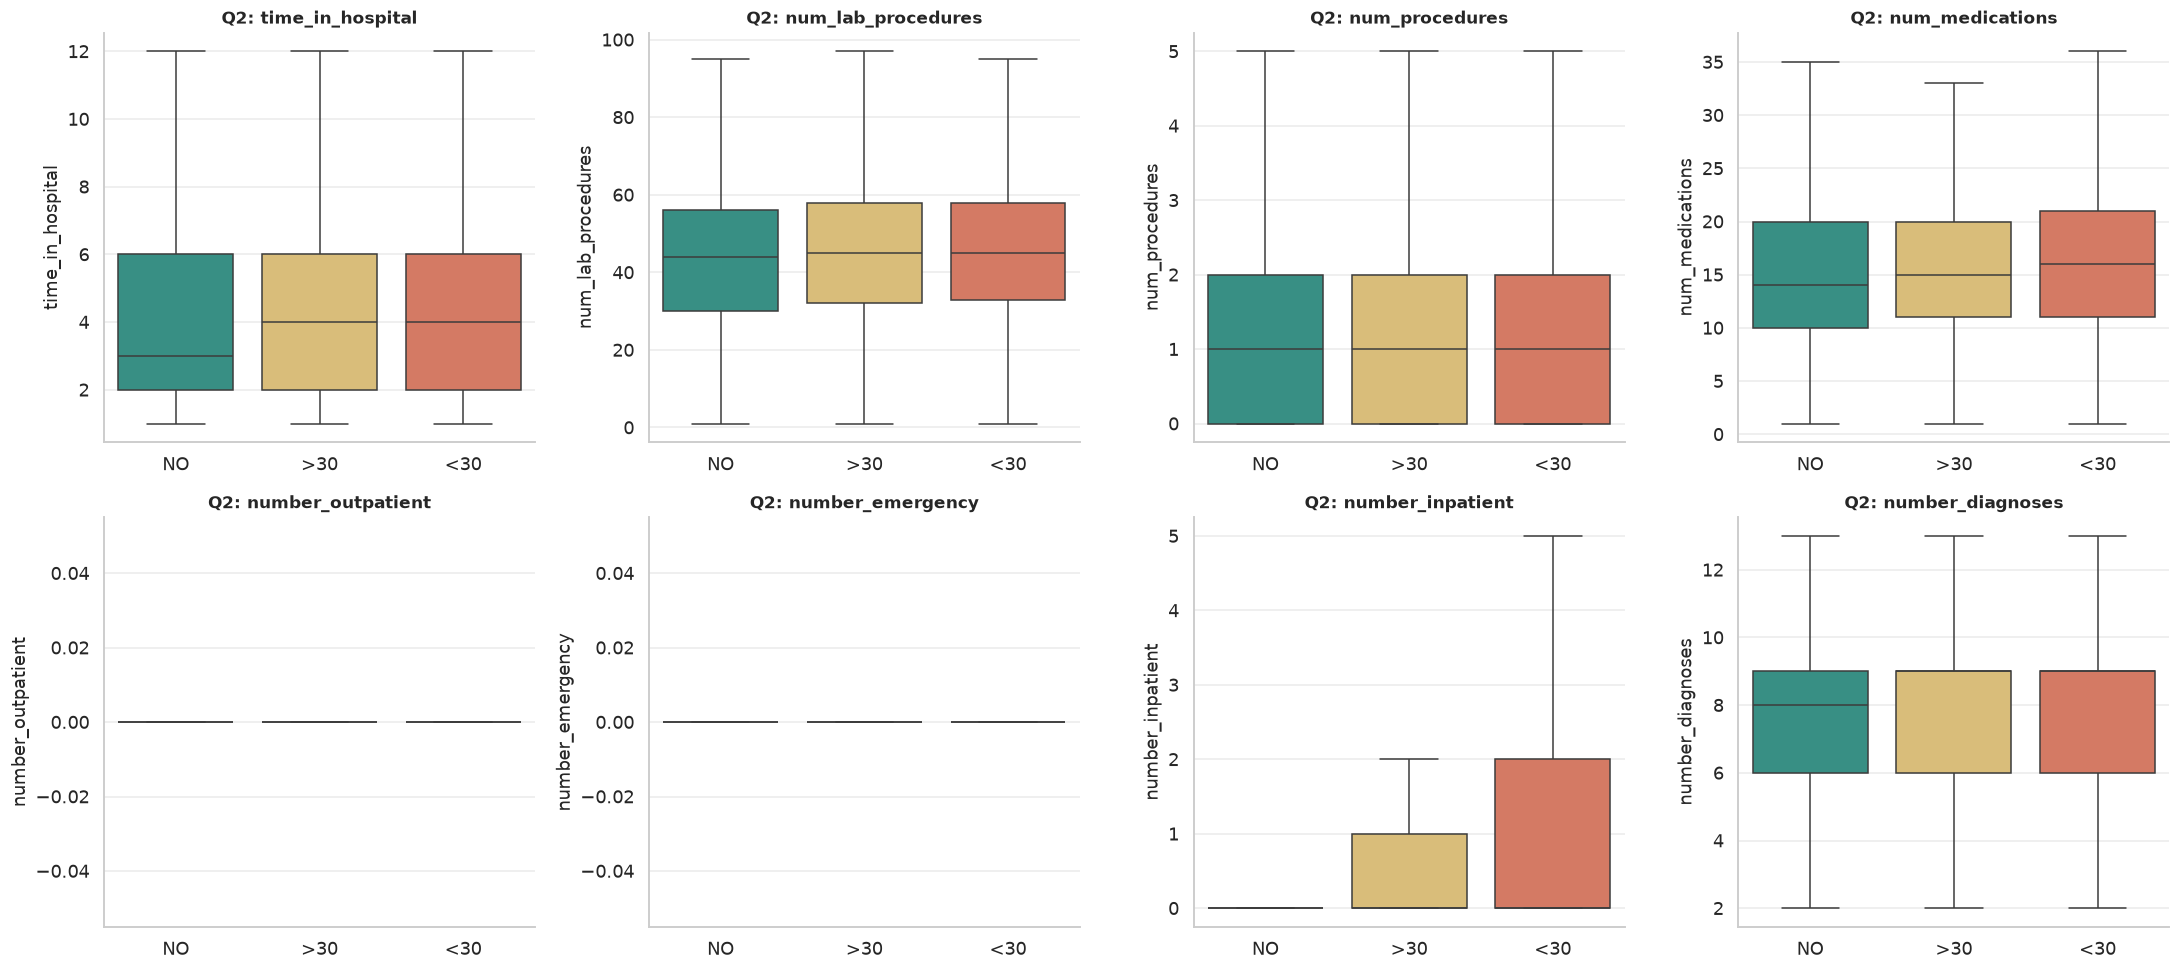

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
for ax, metric in zip(axes, metrics):
    sns.boxplot(data=df, x='readmitted', y=metric, order=READMIT_ORDER, hue='readmitted',
                hue_order=READMIT_ORDER, palette=READMIT_COLORS, legend=False,
                showfliers=False, ax=ax)
    ax.set_title(f'Q2: {metric}', fontsize=11)
    ax.set_xlabel('')
plt.tight_layout()
save_fig('02_utilization_by_readmission')
plt.show()

**Interpretation:** patients readmitted within 30 days tend to have slightly longer stays, more medications, more diagnoses and, most clearly, more prior inpatient visits. Prior utilization appears particularly informative.

## Q3: Which variables appear most strongly associated with 30-day readmission?

**Phase: EDA.** We examine associations while emphasizing that observed associations do **not** imply causation.

--- Q3: Binary Early Readmission Distribution (%) ---
target_early_readmit
0    88.84
1    11.16
Name: proportion, dtype: float64


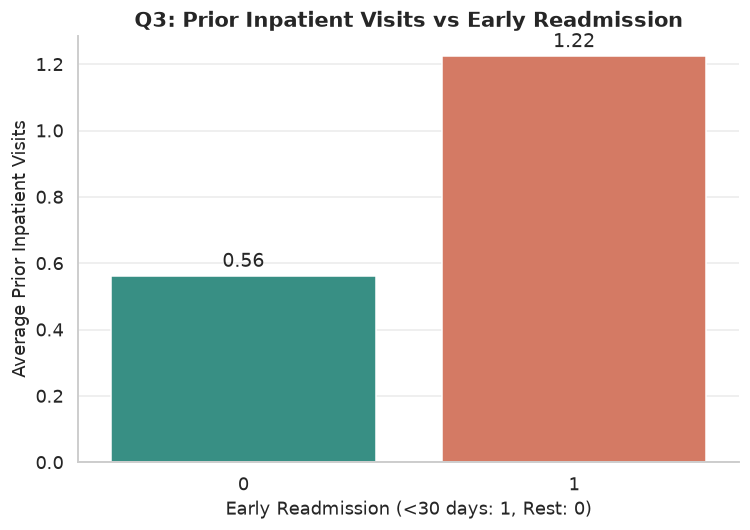

In [12]:
df['target_early_readmit'] = (df['readmitted'] == '<30').astype(int)
overall_rate = df['target_early_readmit'].mean()

print("--- Q3: Binary Early Readmission Distribution (%) ---")
print(df['target_early_readmit'].value_counts(normalize=True).mul(100).round(2))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x='target_early_readmit', y='number_inpatient', hue='target_early_readmit',
            palette={0: RISK_DOWN, 1: RISK_UP}, errorbar=None, legend=False, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
ax.bar_label(ax.containers[1], fmt='%.2f', padding=3)
ax.set_title('Q3: Prior Inpatient Visits vs Early Readmission')
ax.set_xlabel('Early Readmission (<30 days: 1, Rest: 0)')
ax.set_ylabel('Average Prior Inpatient Visits')
plt.tight_layout()
save_fig('03_prior_inpatient_vs_readmit')
plt.show()

### Early readmission rate by demographic and treatment variables

In [13]:
for col in ['age', 'gender', 'race', 'diabetesMed', 'insulin']:
    tab = (df.groupby(col)['target_early_readmit']
             .agg(rate='mean', n='size')
             .sort_values('rate', ascending=False))
    tab['rate'] = tab['rate'].round(3)
    print(f'\nBy {col}:')
    print(tab.to_string())


By age:
           rate      n
age                   
[20-30)   0.142   1657
[80-90)   0.121  17197
[70-80)   0.118  26068
[30-40)   0.112   3775
[60-70)   0.111  22483
[90-100)  0.111   2793
[40-50)   0.106   9685
[50-60)   0.097  17256
[10-20)   0.058    691
[0-10)    0.019    161

By gender:
                  rate      n
gender                       
Female           0.112  54708
Male             0.111  47055
Unknown/Invalid  0.000      3

By race:
                  rate      n
race                         
Caucasian        0.113  76099
AfricanAmerican  0.112  19210
Hispanic         0.104   2037
Asian            0.101    641
Other            0.096   1506

By diabetesMed:
              rate      n
diabetesMed              
Yes          0.116  78363
No           0.096  23403

By insulin:
          rate      n
insulin              
Down     0.139  12218
Up       0.130  11316
Steady   0.111  30849
No       0.100  47383


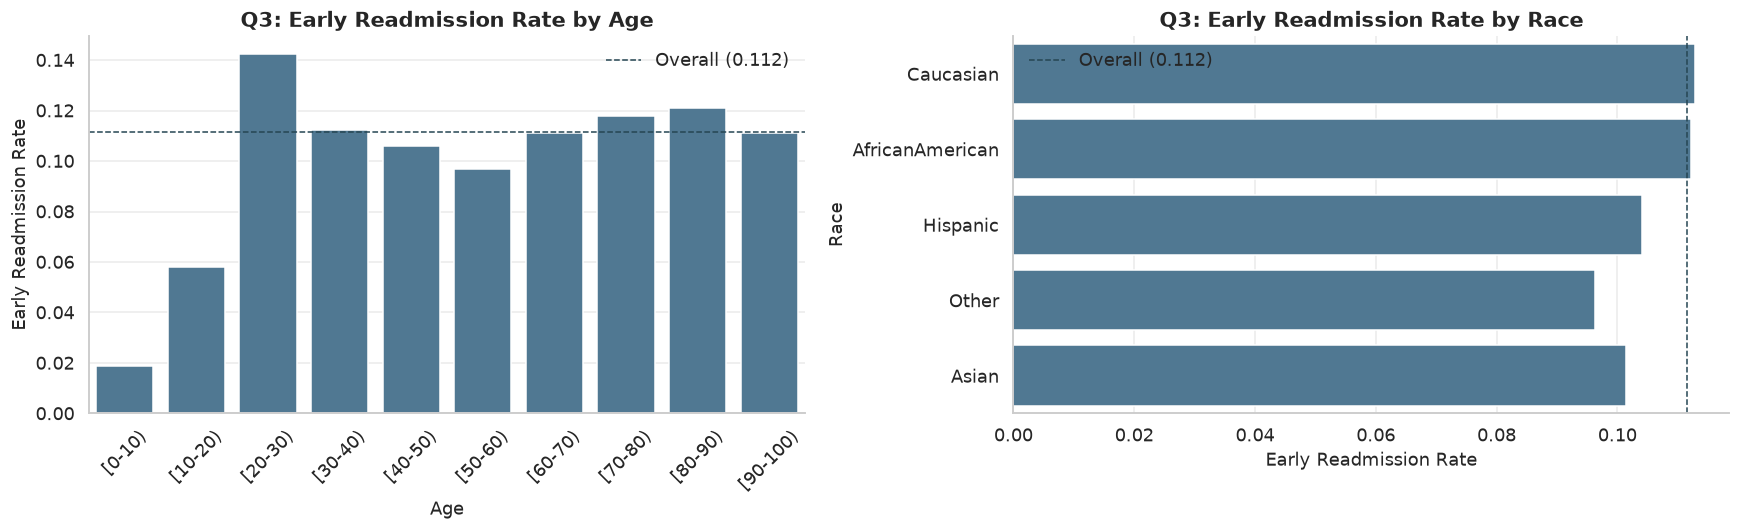

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df, x='age', y='target_early_readmit', order=AGE_ORDER, color=BLUE,
            errorbar=None, ax=axes[0])
axes[0].axhline(overall_rate, color=NEUTRAL, linestyle='--', linewidth=1, label=f'Overall ({overall_rate:.3f})')
axes[0].set_title('Q3: Early Readmission Rate by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Early Readmission Rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(frameon=False)

sns.barplot(data=df, y='race', x='target_early_readmit', order=df['race'].value_counts().index,
            color=BLUE, errorbar=None, ax=axes[1])
axes[1].axvline(overall_rate, color=NEUTRAL, linestyle='--', linewidth=1, label=f'Overall ({overall_rate:.3f})')
axes[1].set_title('Q3: Early Readmission Rate by Race')
axes[1].set_xlabel('Early Readmission Rate')
axes[1].set_ylabel('Race')
axes[1].legend(frameon=False)

plt.tight_layout()
save_fig('03_rate_by_age_race')
plt.show()

### Correlation of numeric variables with early readmission

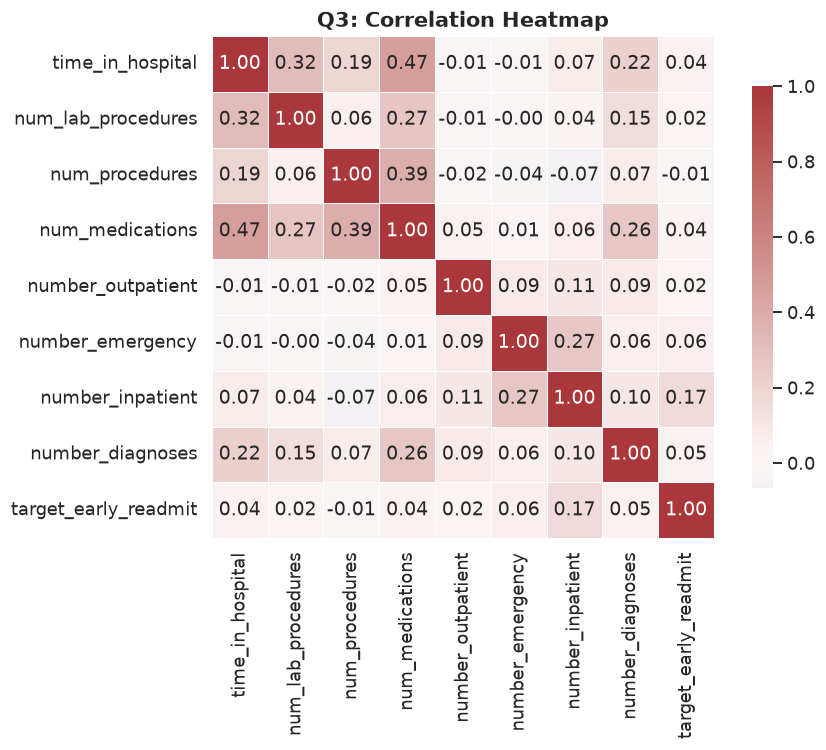

In [15]:
corr_cols = metrics + ['target_early_readmit']
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=CMAP_DIV, center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Q3: Correlation Heatmap')
plt.tight_layout()
save_fig('03_correlation_heatmap')
plt.show()

Pearson correlation with early readmission:
number_inpatient      0.165
number_emergency      0.061
number_diagnoses      0.050
time_in_hospital      0.044
num_medications       0.038
num_lab_procedures    0.020
number_outpatient     0.019
num_procedures       -0.012


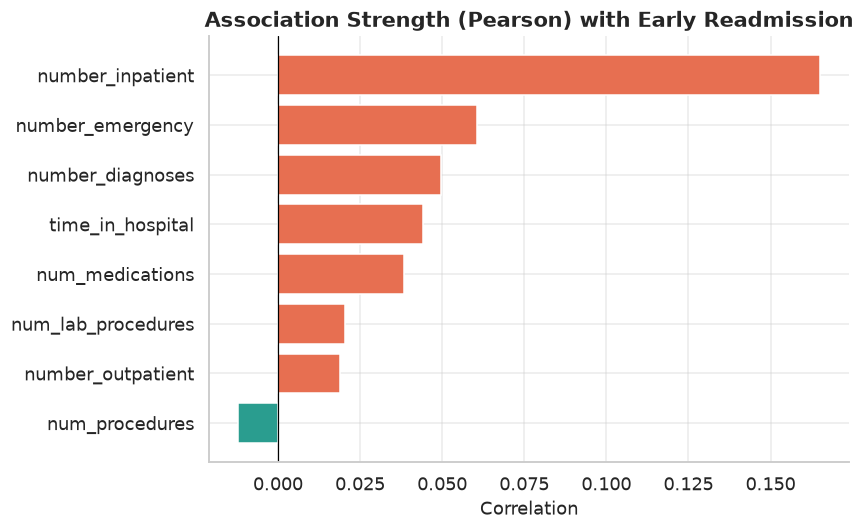

In [16]:
corr_target = (corr['target_early_readmit'].drop('target_early_readmit')
                   .sort_values(key=abs, ascending=False))
print('Pearson correlation with early readmission:')
print(corr_target.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = [RISK_UP if c > 0 else RISK_DOWN for c in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Association Strength (Pearson) with Early Readmission')
ax.set_xlabel('Correlation')
plt.tight_layout()
save_fig('03_numeric_associations')
plt.show()

**Note:** `number_inpatient` shows the strongest linear association among the numeric features. That is expected (prior utilization predicts future utilization) but is not causal proof. Demographic differences are visible but small compared with utilization history.

## Data Preparation for Modeling

**Phase: Data Preparation (آماده‌سازی داده‌ها).** Key decisions:
1. Drop identifiers (`encounter_id`) and high-missing / near-constant columns (`weight`, `max_glu_serum`, `A1Cresult`, `medical_specialty`, `payer_code`, `examide`, `citoglipton`).
2. Keep `patient_nbr` **only** to build a patient-level split; it is never a feature.
3. Group the free-text ICD-9 diagnosis codes into broad clinical categories.
4. Keep the most informative medication fields (`metformin`, `insulin`, `change`, `diabetesMed`).
5. Treat the admission / discharge / source ids as **categorical** codes (they are labels, not quantities).
6. Imputation and scaling happen **inside** the sklearn pipelines, so they are fit on the training data only.

In [17]:
def map_diag(code):
    # Map an ICD-9 code to a broad clinical category (simplified grouping).
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith(('V', 'E')):
        return 'Other'
    try:
        n = int(float(code))          # 459.9 -> 459, 250.83 -> 250
    except ValueError:
        return 'Other'
    if 390 <= n <= 459 or n == 785:
        return 'Circulatory'
    if 460 <= n <= 519 or n == 786:
        return 'Respiratory'
    if 520 <= n <= 579 or n == 787:
        return 'Digestive'
    if n == 250:
        return 'Diabetes'
    if 800 <= n <= 999:
        return 'Injury'
    if 710 <= n <= 739:
        return 'Musculoskeletal'
    if 580 <= n <= 629 or n == 788:
        return 'Genitourinary'
    if 140 <= n <= 239:
        return 'Neoplasms'
    return 'Other'

for i in (1, 2, 3):
    df[f'diag{i}_cat'] = df[f'diag_{i}'].apply(map_diag)

print(df['diag1_cat'].value_counts())

diag1_cat
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Missing               21
Name: count, dtype: int64


In [18]:
# ---- Feature definitions -------------------------------------------------
ID_FEATURES = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

# Minimal baseline feature set
NUMERIC_BASE = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient',
                'number_emergency', 'number_inpatient', 'number_diagnoses']
CATEGORICAL_BASE = ['race', 'gender', 'age']

# Extended feature set
NUMERIC_FULL = NUMERIC_BASE + ['num_procedures']
CATEGORICAL_FULL = (CATEGORICAL_BASE + ID_FEATURES +
                    ['diag1_cat', 'diag2_cat', 'diag3_cat'] +
                    ['metformin', 'insulin', 'change', 'diabetesMed'])

df_model = df[NUMERIC_FULL + CATEGORICAL_FULL + ['patient_nbr', 'target_early_readmit']].copy()
df_model[ID_FEATURES] = df_model[ID_FEATURES].astype(str)   # codes, not quantities

print('Baseline features:', NUMERIC_BASE + CATEGORICAL_BASE)
print('Extended features:', NUMERIC_FULL + CATEGORICAL_FULL)
print('Modeling frame:', df_model.shape)

Baseline features: ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'race', 'gender', 'age']
Extended features: ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'num_procedures', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag1_cat', 'diag2_cat', 'diag3_cat', 'metformin', 'insulin', 'change', 'diabetesMed']
Modeling frame: (101766, 23)


### Train / Test Split (patient-level, leakage-aware)

Because one patient can have many encounters, a random **encounter-level** split would put the same patient on both sides and inflate performance. We therefore split the unique `patient_nbr` values, stratified on whether a patient ever had an early readmission so that both sides keep a similar positive rate. All models below share exactly this split.

In [19]:
patient_outcome = df_model.groupby('patient_nbr')['target_early_readmit'].max()

train_patients, test_patients = train_test_split(
    patient_outcome.index.to_numpy(), test_size=0.2,
    stratify=patient_outcome.to_numpy(), random_state=RANDOM_STATE)

assert set(train_patients).isdisjoint(test_patients), 'Patient leakage between train and test!'

train_df = df_model[df_model['patient_nbr'].isin(train_patients)]
test_df = df_model[df_model['patient_nbr'].isin(test_patients)]

y_train, y_test = train_df['target_early_readmit'], test_df['target_early_readmit']

# Baseline (minimal) and extended feature matrices
X_train_base, X_test_base = (train_df[NUMERIC_BASE + CATEGORICAL_BASE],
                             test_df[NUMERIC_BASE + CATEGORICAL_BASE])
X_train, X_test = (train_df[NUMERIC_FULL + CATEGORICAL_FULL],
                   test_df[NUMERIC_FULL + CATEGORICAL_FULL])

print(f'Train: {len(train_df):,} encounters / {len(train_patients):,} patients | positive rate {y_train.mean():.3f}')
print(f'Test:  {len(test_df):,} encounters / {len(test_patients):,} patients | positive rate {y_test.mean():.3f}')

Train: 81,347 encounters / 57,214 patients | positive rate 0.112
Test:  20,419 encounters / 14,304 patients | positive rate 0.112


In [20]:
def make_preprocessor(numeric, categorical):
    # Imputation + scaling / one-hot encoding; fit on training data only (inside the pipeline).
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric_transformer, numeric),
        ('cat', categorical_transformer, categorical),
    ])

# ---- Reusable plotting helpers -------------------------------------------
CLASS_LABELS = ['Not <30', '<30']

def plot_confusion(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_SEQ, cbar=False,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    return cm

def plot_lr_coefficients(pipe, title, fname, top=15):
    # Top-|coef| logistic-regression coefficients, colored by direction of association.
    names = [n.split('__', 1)[1] for n in pipe.named_steps['preprocessor'].get_feature_names_out()]
    coef_df = pd.DataFrame({'feature': names, 'coefficient': pipe.named_steps['classifier'].coef_[0]})
    coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).head(top)
    coef_df['direction'] = np.where(coef_df['coefficient'] > 0, 'Increases risk', 'Decreases risk')

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=coef_df, x='coefficient', y='feature', hue='direction', dodge=False,
                palette={'Increases risk': RISK_UP, 'Decreases risk': RISK_DOWN}, ax=ax)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.legend(title='', frameon=False, loc='lower right')
    plt.tight_layout()
    save_fig(fname)
    plt.show()
    return coef_df

## Q4: Can a baseline model predict readmission risk?

**Phase: Modeling & Evaluation (مدل‌سازی و ارزیابی).** We start with a deliberately minimal baseline (utilization counts + race / gender / age), then add richer features and two further models:
1. **Minimal baseline** — Logistic Regression on 10 features.
2. **Logistic Regression** (extended features) — highly interpretable coefficients.
3. **Decision Tree** — interpretable rules.
4. **Gradient Boosting** — optional stronger comparator that captures non-linear interactions while still allowing post-hoc interpretation (permutation importance).

Class imbalance (~11% positives) is handled with balanced class weights in every model.

### 4.1 Minimal baseline pipeline

In [21]:
baseline_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(NUMERIC_BASE, CATEGORICAL_BASE)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])

baseline_pipeline.fit(X_train_base, y_train)
y_pred_base = baseline_pipeline.predict(X_test_base)
y_prob_base = baseline_pipeline.predict_proba(X_test_base)[:, 1]

print("--- Q4: Baseline Pipeline Classification Report ---")
print(classification_report(y_test, y_pred_base, target_names=CLASS_LABELS))

--- Q4: Baseline Pipeline Classification Report ---
              precision    recall  f1-score   support

     Not <30       0.91      0.70      0.79     18134
         <30       0.16      0.47      0.24      2285

    accuracy                           0.67     20419
   macro avg       0.54      0.58      0.52     20419
weighted avg       0.83      0.67      0.73     20419



#### Confusion matrix

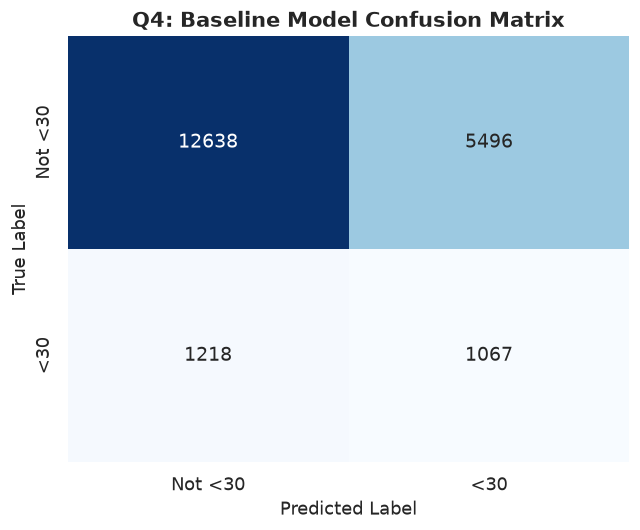

In [22]:
plt.figure(figsize=(6, 5))
plot_confusion(y_test, y_pred_base, 'Q4: Baseline Model Confusion Matrix')
plt.tight_layout()
save_fig('04_cm_baseline')
plt.show()

#### Coefficient plot

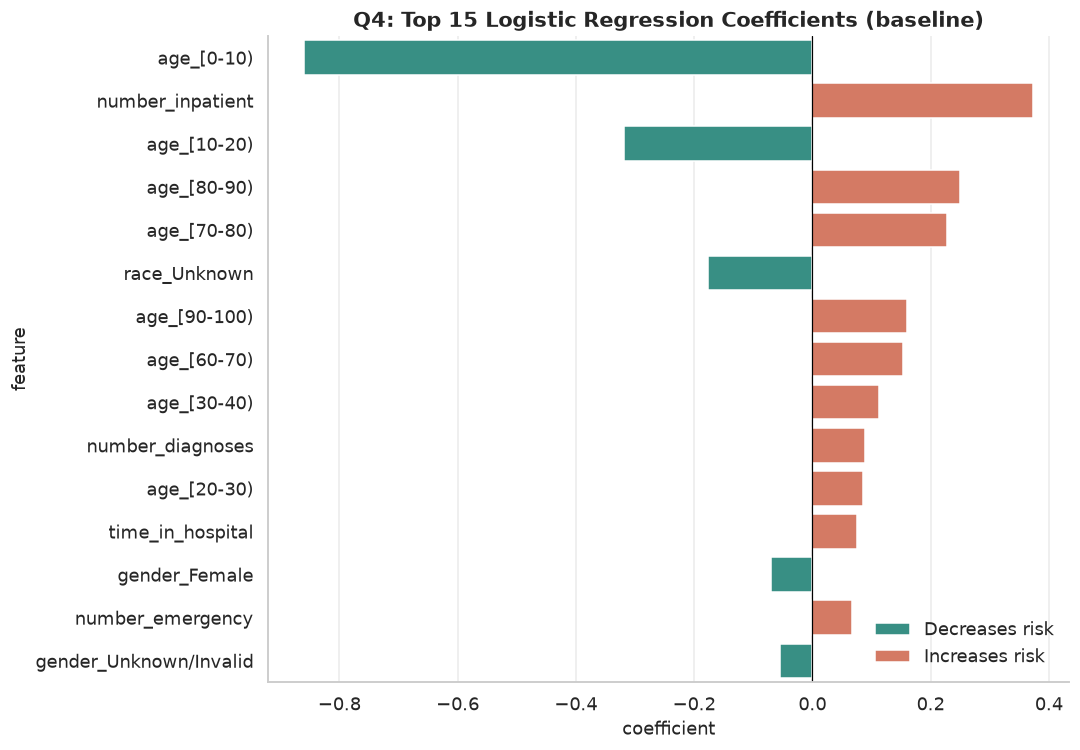

In [23]:
coef_base = plot_lr_coefficients(baseline_pipeline, 'Q4: Top 15 Logistic Regression Coefficients (baseline)',
                                 '04_baseline_coefficients')

### 4.2 Extended models

In [24]:
# Logistic Regression (extended features)
log_reg = Pipeline([
    ('preprocessor', make_preprocessor(NUMERIC_FULL, CATEGORICAL_FULL)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5, random_state=RANDOM_STATE)),
])
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=CLASS_LABELS))

=== Logistic Regression ===
              precision    recall  f1-score   support

     Not <30       0.92      0.68      0.79     18134
         <30       0.18      0.56      0.27      2285

    accuracy                           0.67     20419
   macro avg       0.55      0.62      0.53     20419
weighted avg       0.84      0.67      0.73     20419



In [25]:
# Decision Tree
tree = Pipeline([
    ('preprocessor', make_preprocessor(NUMERIC_FULL, CATEGORICAL_FULL)),
    ('classifier', DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                          class_weight='balanced', random_state=RANDOM_STATE)),
])
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

print('=== Decision Tree (max_depth=6) ===')
print(classification_report(y_test, y_pred_tree, target_names=CLASS_LABELS))

=== Decision Tree (max_depth=6) ===
              precision    recall  f1-score   support

     Not <30       0.92      0.67      0.77     18134
         <30       0.18      0.56      0.27      2285

    accuracy                           0.65     20419
   macro avg       0.55      0.62      0.52     20419
weighted avg       0.84      0.65      0.72     20419



In [26]:
# Optional stronger model: Gradient Boosting (balanced via sample weights, like the other models)
gb = Pipeline([
    ('preprocessor', make_preprocessor(NUMERIC_FULL, CATEGORICAL_FULL)),
    ('classifier', GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.08,
                                              subsample=0.8, random_state=RANDOM_STATE)),
])
gb.fit(X_train, y_train, classifier__sample_weight=compute_sample_weight('balanced', y_train))
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting (optional stronger model) ===')
print(classification_report(y_test, y_pred_gb, target_names=CLASS_LABELS))

=== Gradient Boosting (optional stronger model) ===
              precision    recall  f1-score   support

     Not <30       0.93      0.65      0.77     18134
         <30       0.18      0.59      0.27      2285

    accuracy                           0.65     20419
   macro avg       0.55      0.62      0.52     20419
weighted avg       0.84      0.65      0.71     20419



**Why Gradient Boosting?** It captures non-linear interactions (e.g. prior inpatient visits × age × medications) that linear models miss, while still allowing post-hoc interpretation through permutation importance. It is appropriate for tabular clinical data of this size.

## Q5: Is overall accuracy enough?

**Phase: Modeling & Evaluation.** No. With ~11% positives, a model that never predicts an early readmission would already be ~89% accurate. We therefore focus on **recall for the `<30` class** (sensitivity to early readmissions), precision / F1, and threshold-free ROC-AUC and PR-AUC.

In [27]:
predictions = {
    'Baseline LR (minimal features)': (y_pred_base, y_prob_base),
    'Logistic Regression':            (y_pred_lr,   y_prob_lr),
    'Decision Tree':                  (y_pred_tree, y_prob_tree),
    'Gradient Boosting':              (y_pred_gb,   y_prob_gb),
}

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Recall (<30)': recall_score(y_true, y_pred),
        'Precision (<30)': precision_score(y_true, y_pred, zero_division=0),
        'F1 (<30)': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC': average_precision_score(y_true, y_prob),
    }

results = pd.DataFrame([evaluate(n, y_test, p, pr) for n, (p, pr) in predictions.items()]).set_index('Model')
print(f'Majority-class accuracy (always predict "Not <30"): {1 - y_test.mean():.4f}')
results.round(4)

Majority-class accuracy (always predict "Not <30"): 0.8881


,Accuracy,Recall (<30),Precision (<30),F1 (<30),ROC-AUC,PR-AUC
Model,,,,,,
Baseline LR (minimal features),0.6712,0.4670,0.1626,0.2412,0.6264,0.1903
Logistic Regression,0.6695,0.5575,0.1817,0.2741,0.6712,0.2156
Decision Tree,0.6548,0.5641,0.1756,0.2678,0.6577,0.2010
Gradient Boosting,0.6468,0.5851,0.1759,0.2705,0.6748,0.2256


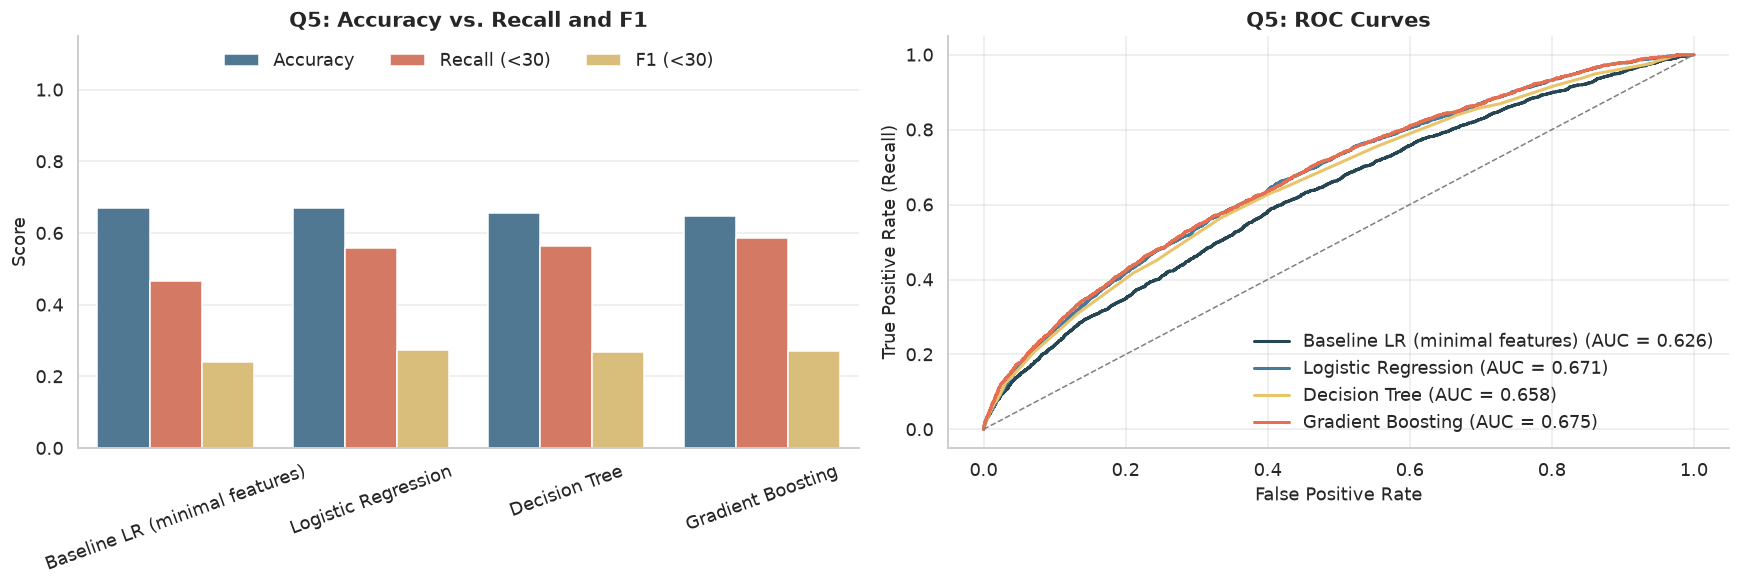

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Accuracy vs. recall: why accuracy alone is misleading
plot_df = results[['Accuracy', 'Recall (<30)', 'F1 (<30)']].reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric',
            palette=[BLUE, RISK_UP, '#E9C46A'], ax=axes[0])
axes[0].set_ylim(0, 1.15)
axes[0].set_xlabel('')
axes[0].set_title('Q5: Accuracy vs. Recall and F1')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(frameon=False, loc='upper center', ncol=3)

# ROC curves
roc_colors = [NEUTRAL, BLUE, '#E9C46A', RISK_UP]
for (name, (_, prob)), color in zip(predictions.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Q5: ROC Curves')
axes[1].legend(frameon=False, loc='lower right')

plt.tight_layout()
save_fig('05_metrics_and_roc')
plt.show()

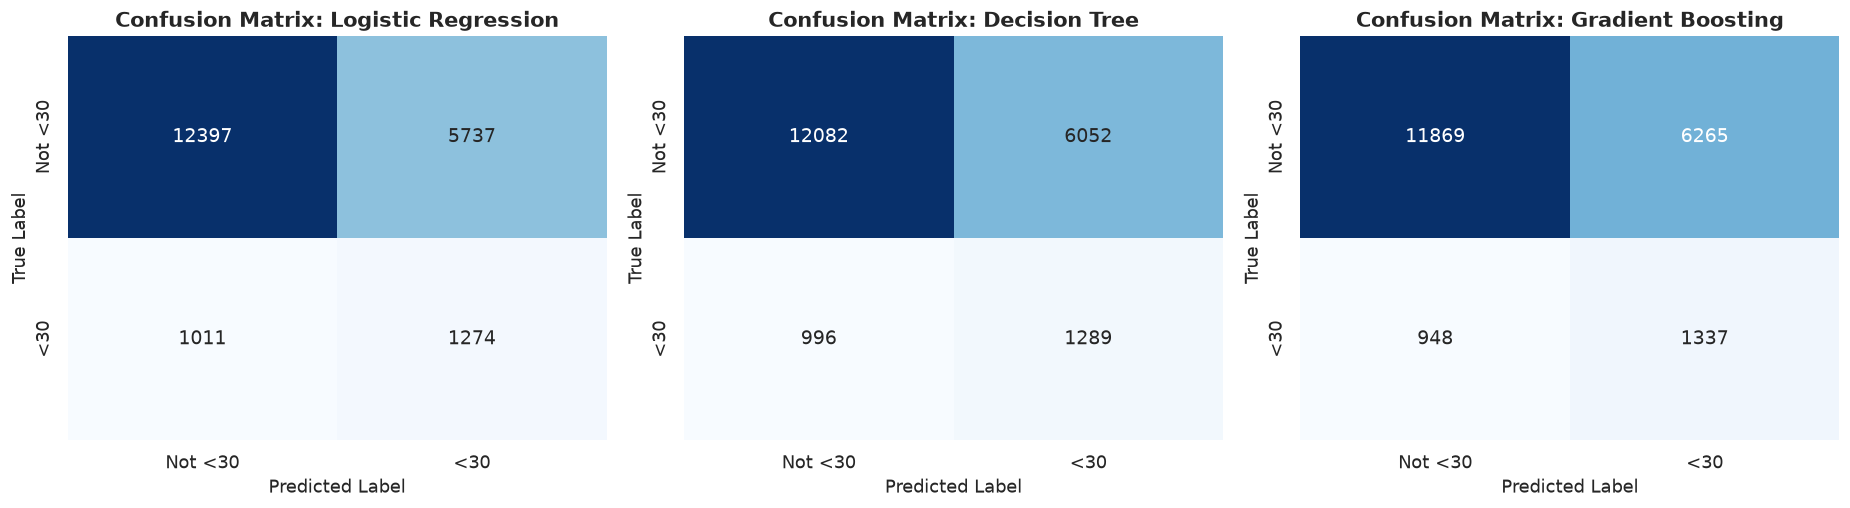

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (name, (pred, _)) in zip(axes, list(predictions.items())[1:]):
    plot_confusion(y_test, pred, f'Confusion Matrix: {name}', ax=ax)
plt.tight_layout()
save_fig('05_confusion_matrices')
plt.show()

**Clinical note on false negatives:** missing an early-readmission case (false negative) means the hospital may fail to provide enhanced discharge planning, medication reconciliation or early follow-up to a high-risk diabetic patient. This can lead to preventable complications, higher costs and worse outcomes. Recall for the `<30` class is therefore prioritized over overall accuracy, while precision shows how many follow-up resources would be spent on patients who would not have been readmitted.

## Q6: Where does the model fail?

**Phase: Modeling & Evaluation.** Error analysis on the test set using the extended Logistic Regression (the most interpretable model).

In [30]:
X_err = X_test.copy()
X_err['y_true'] = y_test.values
X_err['y_pred'] = y_pred_lr
X_err['error_type'] = 'Correct'
X_err.loc[(X_err['y_true'] == 1) & (X_err['y_pred'] == 0), 'error_type'] = 'False Negative'
X_err.loc[(X_err['y_true'] == 0) & (X_err['y_pred'] == 1), 'error_type'] = 'False Positive'

print('Error type counts:')
print(X_err['error_type'].value_counts())

key_vars = ['time_in_hospital', 'num_medications', 'number_inpatient', 'number_diagnoses']
print('\n=== False Negatives: mean of key variables ===')
print(X_err[X_err['error_type'] == 'False Negative'][key_vars].mean().round(2))

print('\n=== Correct Positives (for comparison) ===')
print(X_err[(X_err['y_true'] == 1) & (X_err['y_pred'] == 1)][key_vars].mean().round(2))

Error type counts:
error_type
Correct           13671
False Positive     5737
False Negative     1011
Name: count, dtype: int64

=== False Negatives: mean of key variables ===
time_in_hospital     4.15
num_medications     15.21
number_inpatient     0.22
number_diagnoses     7.26
dtype: float64

=== Correct Positives (for comparison) ===
time_in_hospital     5.23
num_medications     18.01
number_inpatient     2.05
number_diagnoses     8.01
dtype: float64


In [31]:
positives = X_err[X_err['y_true'] == 1]

print('False Negative rate by Age (among true <30):')
print(positives.groupby('age')['error_type'].apply(lambda s: (s == 'False Negative').mean()).round(3).sort_index())

print('\nFalse Negative rate by Race (among true <30):')
print(positives.groupby('race')['error_type'].apply(lambda s: (s == 'False Negative').mean()).round(3))

False Negative rate by Age (among true <30):
age
[10-20)     1.000
[20-30)     0.315
[30-40)     0.479
[40-50)     0.441
[50-60)     0.531
[60-70)     0.461
[70-80)     0.420
[80-90)     0.389
[90-100)    0.426
Name: error_type, dtype: float64

False Negative rate by Race (among true <30):
race
AfricanAmerican    0.455
Asian              0.467
Caucasian          0.432
Hispanic           0.467
Other              0.353
Name: error_type, dtype: float64


**Interpretation:** missed early readmissions look like patients with *lower* prior utilization (fewer prior inpatient visits, fewer diagnoses) than correctly identified cases — the model leans heavily on utilization history, so first-time or low-utilization patients who are nevertheless readmitted early are the hardest to catch.

## Q7: Which features drive the model?

**Phase: Modeling & Evaluation.**

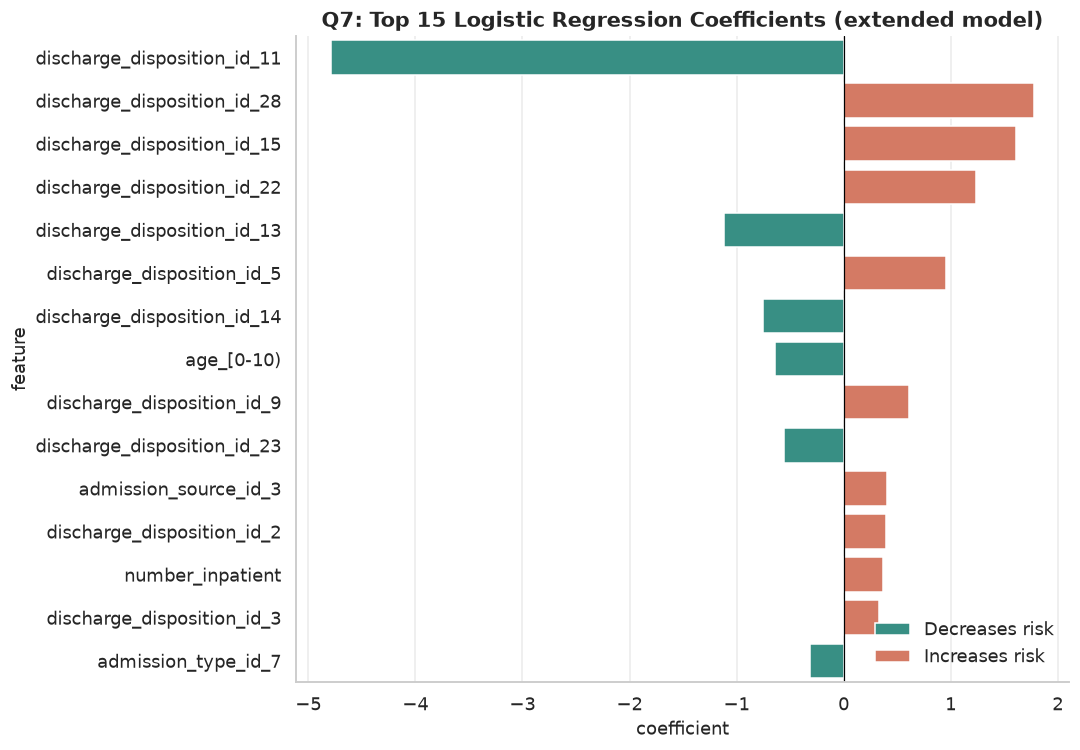

Top 15 features by absolute coefficient (Logistic Regression):
                    feature  coefficient
discharge_disposition_id_11       -4.789
discharge_disposition_id_28        1.780
discharge_disposition_id_15        1.609
discharge_disposition_id_22        1.235
discharge_disposition_id_13       -1.116
 discharge_disposition_id_5        0.958
discharge_disposition_id_14       -0.756
                 age_[0-10)       -0.639
 discharge_disposition_id_9        0.607
discharge_disposition_id_23       -0.558
      admission_source_id_3        0.401
 discharge_disposition_id_2        0.397
           number_inpatient        0.371
 discharge_disposition_id_3        0.329
        admission_type_id_7       -0.319


In [32]:
coef_lr = plot_lr_coefficients(log_reg, 'Q7: Top 15 Logistic Regression Coefficients (extended model)',
                               '07_lr_coefficients')
print('Top 15 features by absolute coefficient (Logistic Regression):')
print(coef_lr[['feature', 'coefficient']].round(3).to_string(index=False))

**Caution:** coefficients indicate association after controlling for the other variables in the model. They are **not** causal effects.

**Data caveat:** several of the largest coefficients (and the permutation importance of `discharge_disposition_id`) come from discharge codes such as *expired* and *hospice*. Patients who died or went to hospice cannot be readmitted, so these codes mostly reflect how the outcome is recorded rather than clinical risk. Published analyses of this dataset usually exclude those encounters; this is worth considering before using the coefficients clinically.

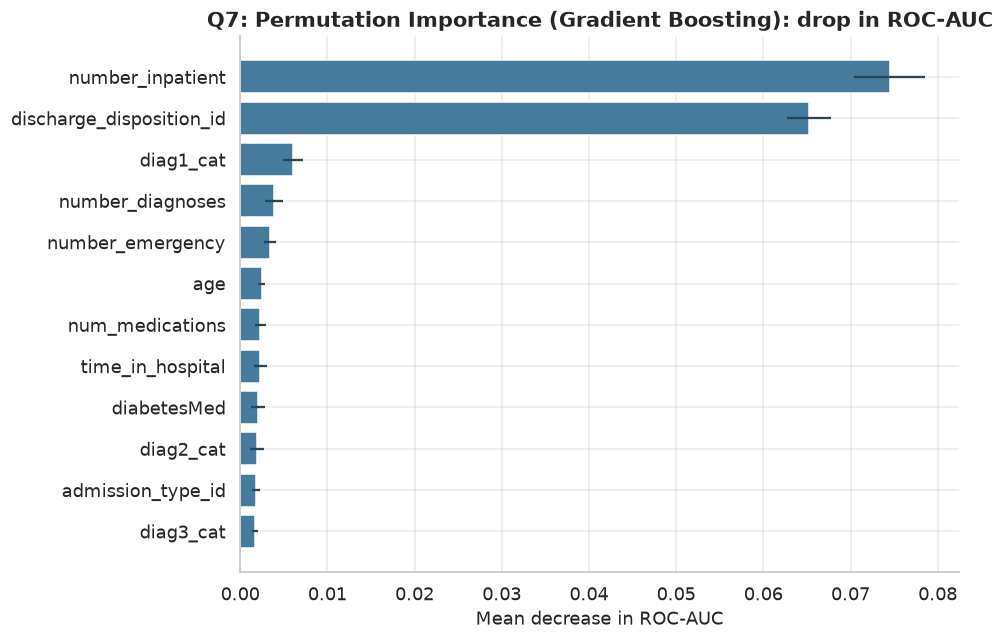

                 feature  importance    std
        number_inpatient      0.0745 0.0041
discharge_disposition_id      0.0652 0.0025
               diag1_cat      0.0061 0.0011
        number_diagnoses      0.0039 0.0010
        number_emergency      0.0034 0.0007
                     age      0.0025 0.0004
         num_medications      0.0023 0.0006
        time_in_hospital      0.0023 0.0007
             diabetesMed      0.0021 0.0008
               diag2_cat      0.0019 0.0008
       admission_type_id      0.0018 0.0004
               diag3_cat      0.0017 0.0003


In [33]:
# Permutation importance for Gradient Boosting (ROC-AUC is threshold-free, so it is stable under class imbalance)
perm = permutation_importance(gb, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
                              scoring='roc_auc')
perm_df = (pd.DataFrame({'feature': X_test.columns, 'importance': perm.importances_mean,
                         'std': perm.importances_std})
             .sort_values('importance', ascending=False))

top_perm = perm_df.head(12)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_perm['feature'], top_perm['importance'], xerr=top_perm['std'], color=BLUE, ecolor=NEUTRAL)
ax.invert_yaxis()
ax.set_title('Q7: Permutation Importance (Gradient Boosting): drop in ROC-AUC')
ax.set_xlabel('Mean decrease in ROC-AUC')
plt.tight_layout()
save_fig('07_gb_permutation_importance')
plt.show()
print(perm_df.head(12).round(4).to_string(index=False))

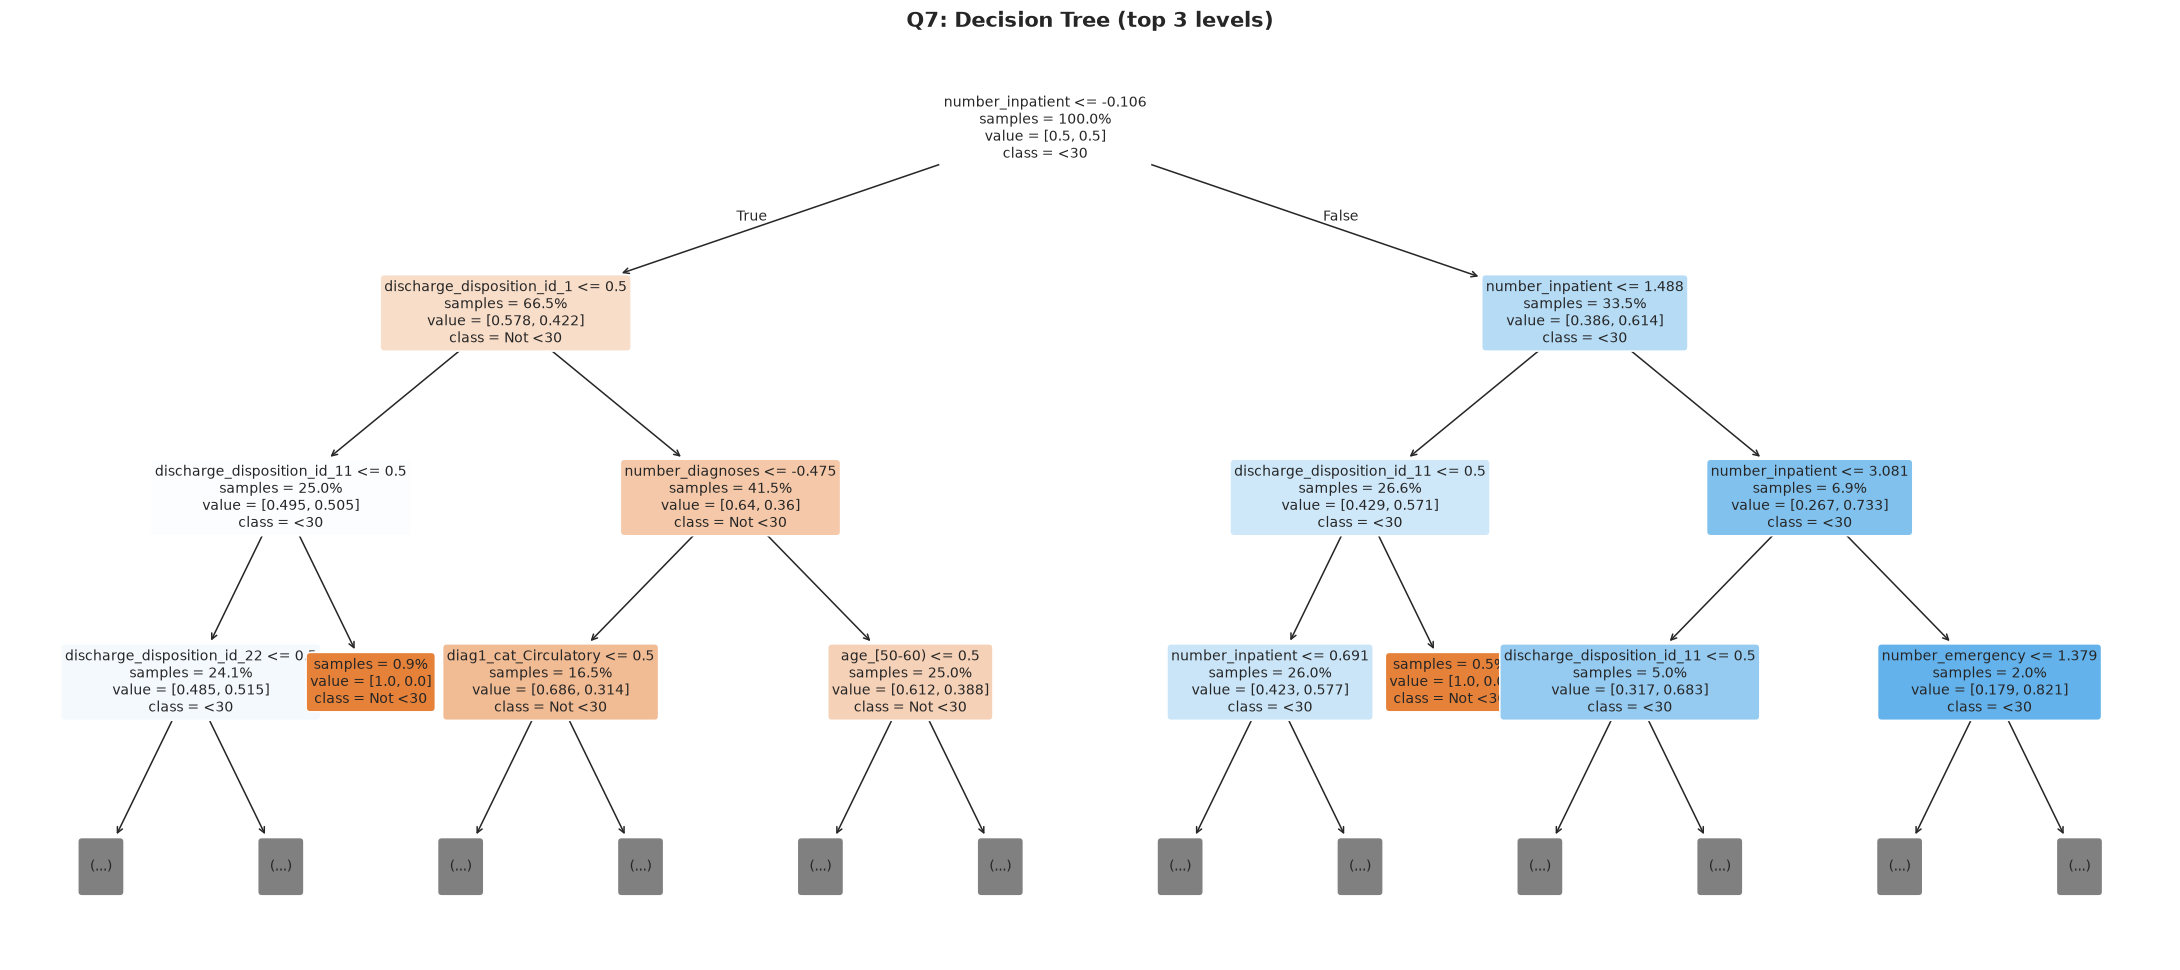

In [34]:
# Interpretable rules: the top of the decision tree
tree_clf = tree.named_steps['classifier']
tree_features = [n.split('__', 1)[1] for n in tree.named_steps['preprocessor'].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(tree_clf, max_depth=3, feature_names=tree_features, class_names=CLASS_LABELS,
          filled=True, rounded=True, proportion=True, impurity=False, fontsize=9, ax=ax)
ax.set_title('Q7: Decision Tree (top 3 levels)')
plt.tight_layout()
save_fig('07_decision_tree_top')
plt.show()

## Q8: Is the model fair across patient subgroups?

**Phase: Modeling & Evaluation + Fairness.** We compare recall and false-negative rate across race, gender and age bracket using the extended Logistic Regression (the primary interpretable model). Groups with fewer than 30 test encounters or fewer than 10 early readmissions are skipped, because their recall estimate would be unreliable.

In [35]:
def subgroup_performance(X_te, y_te, y_pr, group_col, min_n=30, min_pos=10):
    tmp = X_te[[group_col]].copy()
    tmp['y_true'] = np.asarray(y_te)
    tmp['y_pred'] = np.asarray(y_pr)
    rows = []
    for grp, sub in tmp.groupby(group_col):
        if len(sub) < min_n or sub['y_true'].sum() < min_pos:
            continue   # too few encounters / early readmissions for a meaningful recall estimate
        rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
        rows.append({'Group': grp, 'N': len(sub), 'Positives': int(sub['y_true'].sum()),
                     'Prevalence': round(sub['y_true'].mean(), 3),
                     'Recall': round(rec, 3), 'FNR': round(1 - rec, 3)})
    return pd.DataFrame(rows).sort_values('Recall')

fair = {col: subgroup_performance(X_test, y_test, y_pred_lr, col) for col in ['race', 'gender', 'age']}
for col, tab in fair.items():
    print(f'=== Fairness by {col.title()} ===')
    print(tab.to_string(index=False), '\n')

=== Fairness by Race ===
          Group     N  Positives  Prevalence  Recall   FNR
          Asian   142         15       0.106   0.533 0.467
       Hispanic   420         45       0.107   0.533 0.467
AfricanAmerican  3735        420       0.112   0.545 0.455
      Caucasian 15308       1728       0.113   0.568 0.432
          Other   354         34       0.096   0.647 0.353 

=== Fairness by Gender ===
 Group     N  Positives  Prevalence  Recall   FNR
  Male  9396       1003       0.107   0.549 0.451
Female 11023       1282       0.116   0.564 0.436 

=== Fairness by Age ===
   Group    N  Positives  Prevalence  Recall   FNR
 [50-60) 3456        335       0.097   0.469 0.531
 [30-40)  710         71       0.100   0.521 0.479
 [60-70) 4588        505       0.110   0.539 0.461
 [40-50) 1975        211       0.107   0.559 0.441
[90-100)  536         68       0.127   0.574 0.426
 [70-80) 5162        590       0.114   0.580 0.420
 [80-90) 3427        424       0.124   0.611 0.389
 [20-30)

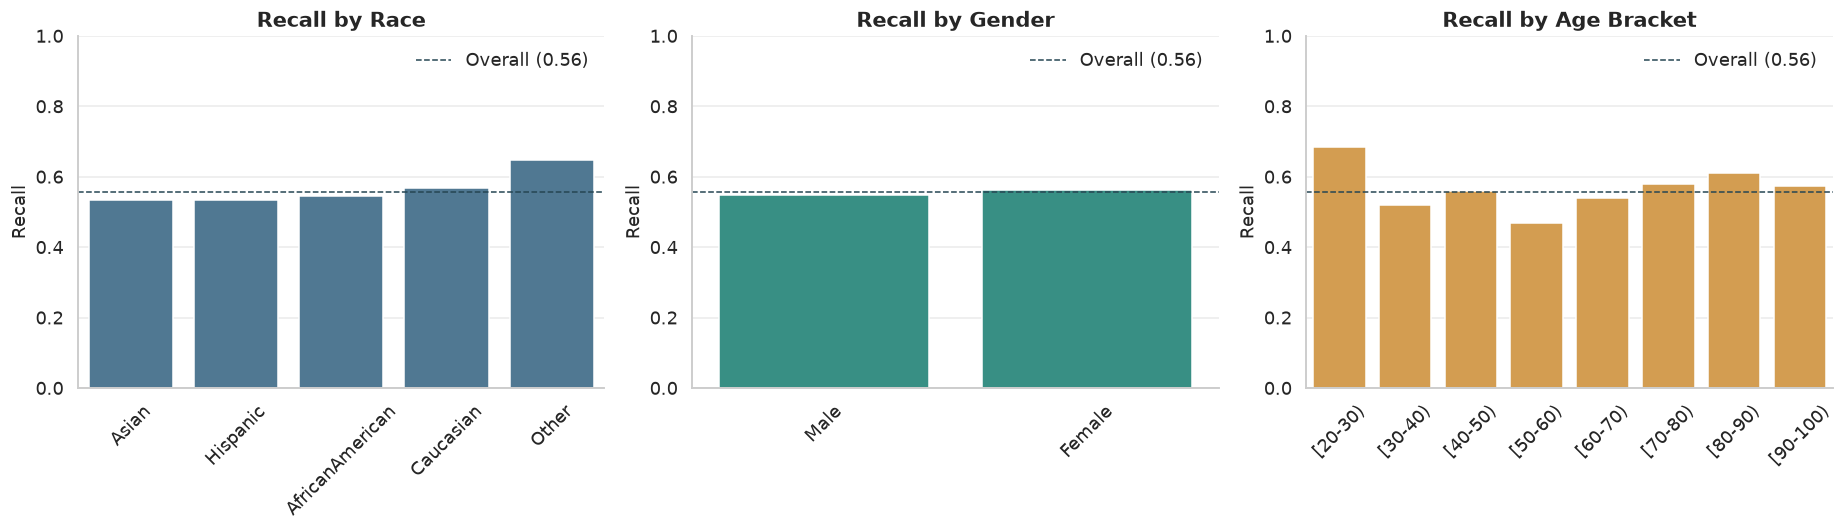

In [36]:
overall_recall = recall_score(y_test, y_pred_lr)
panels = [('race', 'Recall by Race', BLUE), ('gender', 'Recall by Gender', RISK_DOWN), ('age', 'Recall by Age Bracket', '#E9A03B')]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (col, title, color) in zip(axes, panels):
    tab = fair[col]
    if col == 'age':
        tab = tab.sort_values('Group', key=lambda s: s.map({a: i for i, a in enumerate(AGE_ORDER)}))
    sns.barplot(data=tab, x='Group', y='Recall', color=color, ax=ax)
    ax.axhline(overall_recall, color=NEUTRAL, linestyle='--', linewidth=1, label=f'Overall ({overall_recall:.2f})')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
save_fig('08_fairness_recall')
plt.show()

**Interpretation:** performance is not equal across subgroups. Differences should be reported transparently; plausible drivers include sample-size imbalance, differing base rates (see the `Prevalence` column) and residual confounding.

## Q9: What should a hospital administrator or clinician take from this analysis?

**Phase: Report Writing (گزارش‌نویسی).**

In [37]:
best_auc = results['ROC-AUC'].idxmax()
best_recall = results['Recall (<30)'].idxmax()
gaps = {c: (t['Recall'].max() - t['Recall'].min()) for c, t in fair.items()}

print(f"Early readmission (<30 days) prevalence:   {df['target_early_readmit'].mean():.1%} of encounters")
print(f"Strongest numeric correlate:               {corr_target.index[0]} (r = {corr_target.iloc[0]:.3f})")
print(f"Best ROC-AUC:                              {best_auc} ({results.loc[best_auc, 'ROC-AUC']:.3f})")
print(f"Best recall for <30:                       {best_recall} ({results.loc[best_recall, 'Recall (<30)']:.3f})")
print('Recall gap between best and worst subgroup: ' + ', '.join(f'{c}: {g:.2f}' for c, g in gaps.items()))
print()
results.round(3)

Early readmission (<30 days) prevalence:   11.2% of encounters
Strongest numeric correlate:               number_inpatient (r = 0.165)
Best ROC-AUC:                              Gradient Boosting (0.675)
Best recall for <30:                       Gradient Boosting (0.585)
Recall gap between best and worst subgroup: race: 0.11, gender: 0.01, age: 0.22



,Accuracy,Recall (<30),Precision (<30),F1 (<30),ROC-AUC,PR-AUC
Model,,,,,,
Baseline LR (minimal features),0.671,0.467,0.163,0.241,0.626,0.190
Logistic Regression,0.670,0.558,0.182,0.274,0.671,0.216
Decision Tree,0.655,0.564,0.176,0.268,0.658,0.201
Gradient Boosting,0.647,0.585,0.176,0.270,0.675,0.226


### Clinical & operational summary

**Main patterns observed**
- Early readmission (<30 days) occurs in roughly 11% of encounters; the majority of encounters are never readmitted.
- The strongest associated factor is prior inpatient utilization, followed by length of stay, medication count and number of diagnoses.
- Demographic patterns exist but are weaker than utilization history.

**Model performance**
- The models show *modest* discrimination; overall accuracy is not the right metric. Recall for the critical `<30` class is prioritized, and the results table above shows the trade-off with precision.
- The extended feature set and Gradient Boosting are compared with the minimal baseline in the Q5 table; any gain from the added complexity should be weighed against interpretability.

**Fairness findings**
- Recall and false-negative rates vary across race, gender and age brackets (see Q8). The differences may stem from sample size, base-rate differences or unmeasured social determinants. The model should not be used to make unequal decisions across groups without further mitigation and prospective validation.

**Limitations (critical)**
- Data period 1999–2008 (before many modern diabetes therapies and care pathways); ICD-9 coding only.
- High missingness in weight, A1C, glucose serum, specialty and payer.
- No socioeconomic, medication-adherence or post-discharge support variables.
- The split is patient-level, but encounters of one patient are still correlated over time, and there is no external validation on contemporary data.

**Actionable recommendations**
1. Use the model only as a risk-stratification aid for enhanced discharge planning, never for denying care or for automated decisions.
2. Prioritize patients with high prior inpatient utilization for medication reconciliation and early outpatient follow-up.
3. Before any operational deployment: retrain on recent data, add social determinants, perform prospective validation and implement fairness monitoring.
4. Collect structured A1C and medication-adherence data going forward.

*This is an educational risk-stratification exercise, not a deployed clinical decision system.*

## Reproducibility & How to Run

```bash
pip install -r requirements.txt
cd notebooks
jupyter notebook analysis.ipynb
```

Expected layout: `data/diabetic_data.csv` next to the `notebooks/` folder. All figures are saved automatically to `figures/`. The random seed (`RANDOM_STATE = 42`) is fixed for the split and all models.